# 1 - ASK Grundlagen (PRBS-15 NRZ)

## Überblick: Amplitude Shift Keying (ASK)

ASK ist die digitale Variante der Amplitudenmodulation: ein binäres Basisband
(hier PRBS-15 NRZ) steuert die Trägeramplitude.

Unmodulierter Träger:

$$s_c(t) = U_c \cos(2\pi f_c t + \varphi_c)$$

Bipolarer NRZ aus PRBS-Bits $b_k \in \{0, 1\}$ mit Bitdauer $T_b$:

$$d(t) = 2 b_{\lfloor t / T_b \rfloor} - 1 \in \{-1,\,+1\}$$

ASK-Signal mit Modulationsgrad $m \in [0, 1]$:

$$s_{ASK}(t) = U_c \bigl(1 + m\, d(t)\bigr)\cos(2\pi f_c t + \varphi_c)$$

Spezialfälle:
- $m \to 0$: reiner Träger (keine Modulation).
- $m = 1$: Amplituden $\{0, 2\}$ -> klassisches **OOK** (On-Off-Keying).

Aus der Hüllkurve lässt sich der Modulationsgrad ablesen:

$$m = \frac{U_{max} - U_{min}}{U_{max} + U_{min}}$$

## Globale Konfiguration

Alle gemeinsamen Simulationsparameter zentral gesetzt:

- Abtastrate `fs`
- Trägerfrequenz `f_c`
- Anzahl Samples pro Bit `samples_per_bit` (-> Bitrate `R_b = fs / samples_per_bit`)
- Anzahl gesendeter PRBS-Bits `n_bits` (-> `N_sig = samples_per_bit * n_bits`)
- Modulationsgrad `m`
- FFT-Länge `N_fft` und Plot-Fenster `t_plot_ms`

PRBS-15 hat eine Periode von $2^{15} - 1 = 32767$ Bits; mit `n_bits` wählen wir
einen kurzen Ausschnitt zur Anzeige.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve()))

import numpy as np
import matplotlib.pyplot as plt

from lib.plot_style import apply_lab_matplotlib_style

apply_lab_matplotlib_style()

fs = 200_000              # Abtastrate [Hz]
f_c = 20_000.0            # Traegerfrequenz [Hz]
phi_c_deg = 0.0           # Traegerphase [deg]
U_c = 1.0                 # Traegeramplitude

samples_per_bit = 100     # Samples / Bit (-> R_b = fs / samples_per_bit)
n_bits = 180               # Anzahl gesendeter PRBS-15 Bits
m = 0.7                   # Modulationsgrad in [0, 1]

N_sig = samples_per_bit * n_bits
R_b = fs / samples_per_bit
T_b = 1.0 / R_b
T_obs = N_sig / fs

N_fft = 16384             # FFT-Laenge
t_plot_ms = 12.0          # Zeitbereich-Plotdauer [ms]

phi_c = np.deg2rad(phi_c_deg)
t = np.arange(N_sig) / fs
n_plot = min(N_sig, int(t_plot_ms * 1e-3 * fs))

print(f'fs = {fs} Hz, f_c = {f_c} Hz')
print(f'samples_per_bit = {samples_per_bit}  ->  R_b = {R_b:.1f} bit/s,  T_b = {T_b*1e3:.3f} ms')
print(f'n_bits = {n_bits},  N_sig = {N_sig},  T_obs = {T_obs*1e3:.2f} ms')
print(f'm = {m}, N_fft = {N_fft}, t_plot = {t_plot_ms} ms')

fs = 200000 Hz, f_c = 20000.0 Hz
samples_per_bit = 100  ->  R_b = 2000.0 bit/s,  T_b = 0.500 ms
n_bits = 180,  N_sig = 18000,  T_obs = 90.00 ms
m = 0.7, N_fft = 16384, t_plot = 12.0 ms


## PRBS-15 Basisbandsignal

Maximal-length Sequenz aus einem 15-Bit Linear Feedback Shift Register (LFSR)
mit Polynom $x^{15} + x^{14} + 1$:

1. State `reg` mit Startwert `0x7FFF` initialisieren.
2. Pro Schritt das LSB als Ausgangsbit ausgeben.
3. Feedback-Bit aus den getappten Stellen XORen, links einschieben.

Aus der Bitfolge `b[k]` erzeugen wir ein bipolares NRZ-Signal $d(t) \in \{-1, +1\}$,
das je `samples_per_bit` Abtastwerte konstant gehalten wird.

In [2]:
from lib.prbs import prbs_bits

b = prbs_bits(n_bits, order=15)

# Bipolar NRZ: 0 -> -1, 1 -> +1; je Bit samples_per_bit Abtastwerte halten
d_bits = 2.0 * b.astype(np.float64) - 1.0
d_nrz = np.repeat(d_bits, samples_per_bit)[:N_sig]

print(f'PRBS-15: {len(b)} Bits, davon Einsen: {int(b.sum())}, Nullen: {int(len(b) - b.sum())}')
print(f'NRZ-Vektor: {len(d_nrz)} Samples')

PRBS-15: 180 Bits, davon Einsen: 81, Nullen: 99
NRZ-Vektor: 18000 Samples


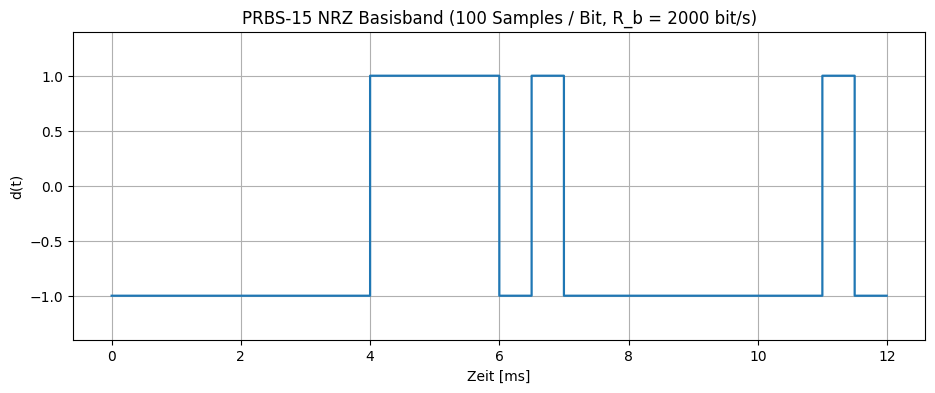

In [3]:
fig, ax = plt.subplots()
ax.plot(t[:n_plot] * 1e3, d_nrz[:n_plot], lw=1.6, drawstyle='steps-post')
ax.set_title(f'PRBS-15 NRZ Basisband ({samples_per_bit} Samples / Bit, R_b = {R_b:.0f} bit/s)')
ax.set_xlabel('Zeit [ms]')
ax.set_ylabel('d(t)')
ax.set_ylim(-1.4, 1.4)
plt.show()

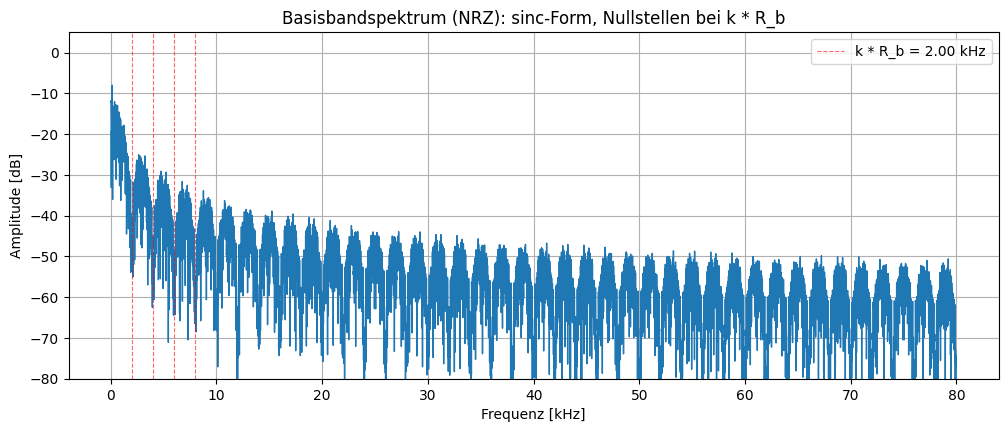

In [4]:
x = np.zeros(N_fft)
x[:min(N_sig, N_fft)] = d_nrz[:min(N_sig, N_fft)]
X = np.fft.fft(x, n=N_fft)
f = np.fft.fftfreq(N_fft, d=1.0 / fs)
mask = f >= 0
f_pos = f[mask]
A_pos = (2.0 / N_fft) * np.abs(X[mask])

f_max_show = min(fs / 2.0, max(5.0 * R_b, 4.0 * f_c))
show = f_pos <= f_max_show

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(f_pos[show] / 1e3, 20 * np.log10(A_pos[show] + 1e-12), lw=1.0)
for k in range(1, 5):
    ax.axvline(k * R_b / 1e3, color='red', ls='--', lw=0.8, alpha=0.6,
               label=(f'k * R_b = {k*R_b/1e3:.2f} kHz' if k == 1 else None))
ax.set_title('Basisbandspektrum (NRZ): sinc-Form, Nullstellen bei k * R_b')
ax.set_xlabel('Frequenz [kHz]')
ax.set_ylabel('Amplitude [dB]')
ax.set_ylim(-80, 5)
ax.legend(loc='upper right')
plt.show()

## ASK-Modulator

Didaktisch in drei Schritten:

1. NRZ-Signal $d(t) \in \{-1, +1\}$ aus dem PRBS-Bitstrom.
2. Hüllkurve $1 + m\, d(t)$, also $\{1-m, 1+m\}$.
3. Multiplikation mit dem Träger.

$$s_{ASK}(t) = U_c \bigl(1 + m\, d(t)\bigr)\cos(2\pi f_c t + \varphi_c)$$

Für einen reinen Hüllkurvendetektor muss $m \le 1$ gelten, sonst kommt es zur
Phasenumtastung (Vorzeichenwechsel der Hüllkurve).

In [5]:
envelope = 1.0 + m * d_nrz
carrier = np.cos(2 * np.pi * f_c * t + phi_c)
s_ask = U_c * envelope * carrier

U_max = float(np.max(envelope))
U_min = float(np.min(envelope))
m_check = (U_max - U_min) / max(1e-12, (U_max + U_min))
print(f'min(envelope) = {U_min:.3f}, max(envelope) = {U_max:.3f}')
print(f'Modulationsgrad aus Huellkurve: m = (U_max - U_min) / (U_max + U_min) = {m_check:.4f}')

min(envelope) = 0.300, max(envelope) = 1.700
Modulationsgrad aus Huellkurve: m = (U_max - U_min) / (U_max + U_min) = 0.7000


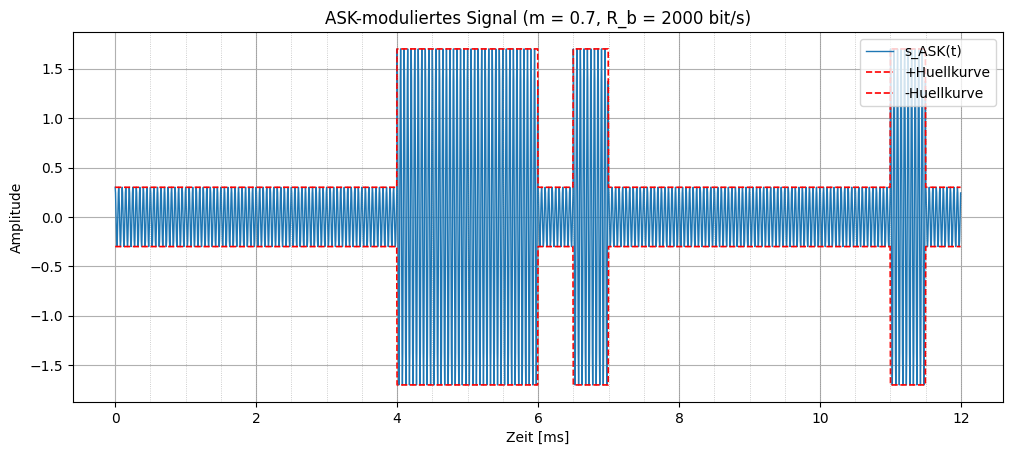

In [6]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(t[:n_plot] * 1e3, s_ask[:n_plot], lw=1.0, label='s_ASK(t)')
ax.plot(t[:n_plot] * 1e3, (U_c * envelope)[:n_plot], 'r--', lw=1.2, label='+Huellkurve')
ax.plot(t[:n_plot] * 1e3, (-U_c * envelope)[:n_plot], 'r--', lw=1.2, label='-Huellkurve')
for k in range(1, n_plot // samples_per_bit + 1):
    ax.axvline(k * T_b * 1e3, color='gray', ls=':', lw=0.6, alpha=0.5)
ax.set_title(f'ASK-moduliertes Signal (m = {m}, R_b = {R_b:.0f} bit/s)')
ax.set_xlabel('Zeit [ms]')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')
plt.show()

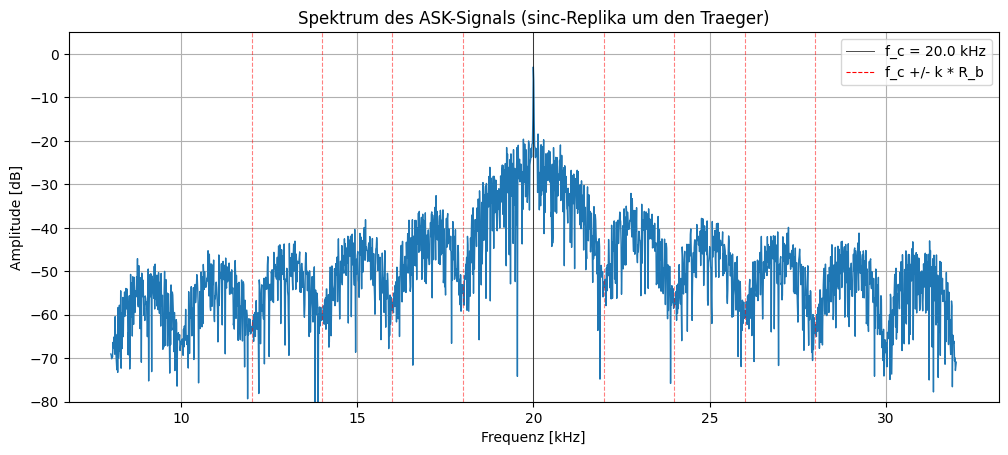

In [7]:
x = np.zeros(N_fft)
x[:min(N_sig, N_fft)] = s_ask[:min(N_sig, N_fft)]
X = np.fft.fft(x, n=N_fft)
f = np.fft.fftfreq(N_fft, d=1.0 / fs)
mask = f >= 0
f_pos = f[mask]
A_pos = (2.0 / N_fft) * np.abs(X[mask])

show = (f_pos >= max(0.0, f_c - 6 * R_b)) & (f_pos <= f_c + 6 * R_b)

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(f_pos[show] / 1e3, 20 * np.log10(A_pos[show] + 1e-12), lw=1.0)
ax.axvline(f_c / 1e3, color='black', ls='-', lw=0.7, alpha=0.7,
           label=f'f_c = {f_c/1e3:.1f} kHz')
for k in range(1, 5):
    for sgn in (-1, +1):
        ax.axvline((f_c + sgn * k * R_b) / 1e3, color='red', ls='--', lw=0.8, alpha=0.5)
ax.plot([], [], 'r--', lw=0.8, label='f_c +/- k * R_b')
ax.set_title('Spektrum des ASK-Signals (sinc-Replika um den Traeger)')
ax.set_xlabel('Frequenz [kHz]')
ax.set_ylabel('Amplitude [dB]')
ax.set_ylim(-80, 5)
ax.legend(loc='upper right')
plt.show()

## Speichern der modulierten Kurvenform

Die ASK-Wellenform wird zusammen mit allen Metadaten als JSON-Recording in
`recordings/ask.json` abgelegt. Das nachfolgende Notebook
`2-ASK-demod-envelope.ipynb` liest diese Datei wieder ein und demoduliert sie.

In [8]:
from pathlib import Path

from lib.ask_recording import save_ask_recording_v1

rec_dir = Path('recordings')
rec_dir.mkdir(exist_ok=True)
rec_path = rec_dir / 'ask.json'

save_ask_recording_v1(
    rec_path,
    fs_hz=float(fs),
    f_carrier_hz=float(f_c),
    phi_carrier_rad=float(phi_c),
    U_c=float(U_c),
    modulation_index=float(m),
    prbs_order=15,
    samples_per_bit=int(samples_per_bit),
    bit_rate_hz=float(R_b),
    n_bits=int(n_bits),
    n_samples=int(N_sig),
    bits=b,
    samples=s_ask,
)

print(f'Gespeichert: {rec_path.resolve()}')
print(f'  fs = {fs} Hz, f_c = {f_c} Hz, m = {m}')
print(f'  samples_per_bit = {samples_per_bit}, n_bits = {n_bits}, n_samples = {N_sig}')
print(f'  Datei groesse: {rec_path.stat().st_size / 1024:.1f} KiB')

Gespeichert: C:\_Git\KT-workspace\lab_suite\labs\09_01_LABOR-8-solution\recordings\ask.json
  fs = 200000 Hz, f_c = 20000.0 Hz, m = 0.7
  samples_per_bit = 100, n_bits = 180, n_samples = 18000
  Datei groesse: 366.9 KiB


## ToDo

- Beschreibe in eigenen Worten die mathematischen Funktionen der Pythoncode-Zellen.
- Welche Aussagekraft haben die gezeigten Plots, was kann man daraus ableiten?